Костин Арсений, 8Е21, вариант 3.

# Лабораторная работа №4. Разработка алгоритма определения лиц.

<p>Цель: на практике закрепить полученные в ходе курса знания, в том числе по машинному обучению и нейронным сетям для решения задачи детектирования лиц и классификации лиц на мужчин и женщин.
<p>Ход работы: в ходе первой и второй лабораторной каждый из студентов собрал свои фотографии. Данную выборку можно использовать в качестве обучающей выборки для синтеза алгоритмов. Разметку данных каждый студент проводит сам. Алгоритм детектирования и классификации может быть любым.

<p><b>Выбранный метод: HOG + Linear SVM</b>

<p>HOG (Histogram of Oriented Gradients) описывает форму объекта через распределение направлений градиентов — ровно тот же принцип, что использовался в детекторе Харриса в лабе 2, только там мы считали $I_x$, $I_y$ для поиска углов, а здесь строим из них гистограммы для описания внешнего вида патча.

<p>SVM (Support Vector Machine) ищет гиперплоскость, максимально разделяющую два класса в пространстве HOG-признаков.

In [1]:
import numpy as np
import cv2
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import Image
%matplotlib inline
import math
import os
import pickle

import lab1_functions as lb1
import lab2_functions as lb2
import lab3_functions as lb3
from collections import deque

from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.datasets import fetch_lfw_people

# Настройка графиков по ГОСТ: шрифт с засечками, 14pt
plt.rcParams.update({
    'font.family':      'serif',
    'font.serif':       ['Times New Roman', 'DejaVu Serif', 'Liberation Serif'],
    'font.size':        14,
    'axes.titlesize':   14,
    'axes.labelsize':   14,
    'xtick.labelsize':  12,
    'ytick.labelsize':  12,
    'legend.fontsize':  12,
    'figure.dpi':       100,
})

print(os.getcwd())
print(os.listdir())

/Users/arseniikostin/cv-labs-sem8/labs
['sample_image2.png', 'sample_image3.png', 'gradient.png', 'histfunc.png', 'lab2.py', 'output.gif', 'sample_image4.jpg', 'sample_image5.jpg', 'lab1_functions.py', 'sequence1.jpeg', 'sequence6.jpeg', 'sequence7.jpeg', '__pycache__', 'detector_model.pkl', 'doodles.ipynb', 'sequence8.jpeg', 'lb5cv.png', 'lab2.ipynb', 'sequence4.jpeg', 'gender_model.pkl', 'harris1.png', 'sequence5.jpeg', 'lab4test.py', 'lab4.ipynb', 'gpt-stripfunctions.py', 'live_camera.py', 'gaussfunc.png', 'lab1.py', 'lab4_styled.ipynb', 'lab3.ipynb', 'sequence2.jpeg', 'signals.csv', 'clean.ipynb', 'lab3_functions.py', 'stitch.py', 'lab4_functions.py', 'lab1.ipynb', 'lab5.ipynb', 'lab5_styled.ipynb', 'clearoutput.py', 'sample_image.jpg', 'sequence3.jpeg', 'lab2_functions.py', 'combined.ipynb']


# 4.1 Загрузка датасета

Используем LFW (Labeled Faces in the Wild) — открытый датасет из 13 000+ фотографий лиц публичных людей. Параметр `min_faces_per_person=20` оставляет только тех, кого достаточно много — так модель лучше обобщается и не переобучается на единичные примеры.

Разметку по полу делаем вручную через словарь `GENDER_LABELS` — это и есть ручная разметка данных согласно условию лабы.

In [2]:
print('Загружаем датасет LFW...')
lfw = fetch_lfw_people(min_faces_per_person=20, resize=0.5, color=True)

print(f'Изображений: {lfw.images.shape[0]}')
print(f'Размер патча: {lfw.images.shape[1]}x{lfw.images.shape[2]}')
print(f'Персон: {len(lfw.target_names)}')
print('Имена:', lfw.target_names)

Загружаем датасет LFW...
Изображений: 3023
Размер патча: 62x47
Персон: 62
Имена: ['Alejandro Toledo' 'Alvaro Uribe' 'Amelie Mauresmo' 'Andre Agassi'
 'Angelina Jolie' 'Ariel Sharon' 'Arnold Schwarzenegger'
 'Atal Bihari Vajpayee' 'Bill Clinton' 'Carlos Menem' 'Colin Powell'
 'David Beckham' 'Donald Rumsfeld' 'George Robertson' 'George W Bush'
 'Gerhard Schroeder' 'Gloria Macapagal Arroyo' 'Gray Davis'
 'Guillermo Coria' 'Hamid Karzai' 'Hans Blix' 'Hugo Chavez' 'Igor Ivanov'
 'Jack Straw' 'Jacques Chirac' 'Jean Chretien' 'Jennifer Aniston'
 'Jennifer Capriati' 'Jennifer Lopez' 'Jeremy Greenstock' 'Jiang Zemin'
 'John Ashcroft' 'John Negroponte' 'Jose Maria Aznar'
 'Juan Carlos Ferrero' 'Junichiro Koizumi' 'Kofi Annan' 'Laura Bush'
 'Lindsay Davenport' 'Lleyton Hewitt' 'Luiz Inacio Lula da Silva'
 'Mahmoud Abbas' 'Megawati Sukarnoputri' 'Michael Bloomberg' 'Naomi Watts'
 'Nestor Kirchner' 'Paul Bremer' 'Pete Sampras' 'Recep Tayyip Erdogan'
 'Ricardo Lagos' 'Roh Moo-hyun' 'Rudolph Giulian

Присваиваем метки пола вручную. 0 — мужчина, 1 — женщина. Это разметка данных.

Изображений с разметкой пола: 2026
Мужчин: 1844, Женщин: 182


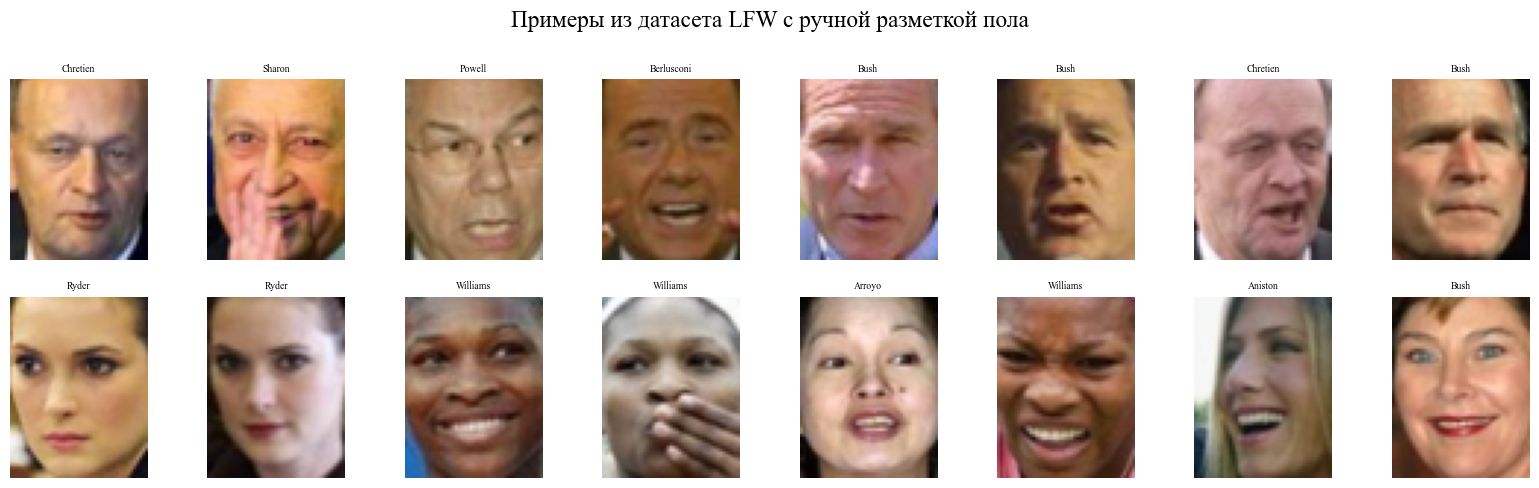

In [3]:
GENDER_LABELS = {
    'Ariel Sharon': 0, 'Colin Powell': 0, 'Donald Rumsfeld': 0,
    'George W Bush': 0, 'Gerhard Schroeder': 0, 'Hugo Chavez': 0,
    'Tony Blair': 0, 'Junichiro Koizumi': 0, 'Jean Chretien': 0,
    'John Ashcroft': 0, 'Vladmir Putin': 0, 'Hamid Karzai': 0,
    'Luiz Inacio Lula da Silva': 0, 'Jacques Chirac': 0, 'Jiang Zemin': 0,
    'Vicente Fox': 0, 'Silvio Berlusconi': 0, 'Alejandro Toledo': 0,
    'John Snow': 0, 'Arnold Schwarzenegger': 0,
    'Lleyton Hewitt': 0, 'Andre Agassi': 0, 'Tiger Woods': 0,
    'Jennifer Aniston': 1, 'Halle Berry': 1, 'Laura Bush': 1,
    'Serena Williams': 1, 'Winona Ryder': 1,
    'Gloria Macapagal Arroyo': 1, 'Condoleezza Rice': 1,
}

gender_labels = []
valid_indices = []

for i, target_id in enumerate(lfw.target):
    name = lfw.target_names[target_id]
    if name in GENDER_LABELS:
        gender_labels.append(GENDER_LABELS[name])
        valid_indices.append(i)

images_valid  = lfw.images[valid_indices]
gender_labels = np.array(gender_labels)

print(f'Изображений с разметкой пола: {len(images_valid)}')
print(f'Мужчин: {(gender_labels == 0).sum()}, Женщин: {(gender_labels == 1).sum()}')

f, axes = plt.subplots(2, 8, figsize=(16, 5))
for row, gender in enumerate([0, 1]):
    idxs = np.where(gender_labels == gender)[0][:8]
    for col, idx in enumerate(idxs):
        axes[row, col].imshow(images_valid[idx])
        name = lfw.target_names[lfw.target[valid_indices[idx]]]
        axes[row, col].set_title(name.split()[-1], fontsize=7)
        axes[row, col].axis('off')
axes[0, 0].set_ylabel('Мужчины', fontsize=10)
axes[1, 0].set_ylabel('Женщины', fontsize=10)
plt.suptitle('Примеры из датасета LFW с ручной разметкой пола')
plt.tight_layout()
plt.show()

# 4.2 HOG-дескриптор

HOG — Histogram of Oriented Gradients. Алгоритм пошагово:

**Шаг 1 — градиенты.** Для каждого пикселя считаем $I_x$ и $I_y$ через центральные разности — ровно так же, как в лабе 2 при вычислении детектора Харриса. Из градиентов получаем магнитуду и угол:

$$M = \sqrt{I_x^2 + I_y^2}, \quad \theta = \arctan\!\left(\frac{I_y}{I_x}\right) \bmod 180°$$

Угол берём по модулю 180° (неориентированный) — нам не важно смотрит ли граница вверх или вниз.

**Шаг 2 — ячейки.** Делим изображение на клетки 8×8 пикселей. В каждой ячейке строим гистограмму из 9 бинов по углам (0–180°), взвешенную по магнитуде.

**Шаг 3 — блоки.** Объединяем соседние 2×2 ячейки в блок и нормируем его вектор на L2-норму. Нормировка делает дескриптор устойчивым к изменению освещения.

**Результат** — конкатенация всех нормированных блоков.

### Шаг 1: градиенты

Перевод в grayscale через взвешенную сумму каналов, потом центральные разности.

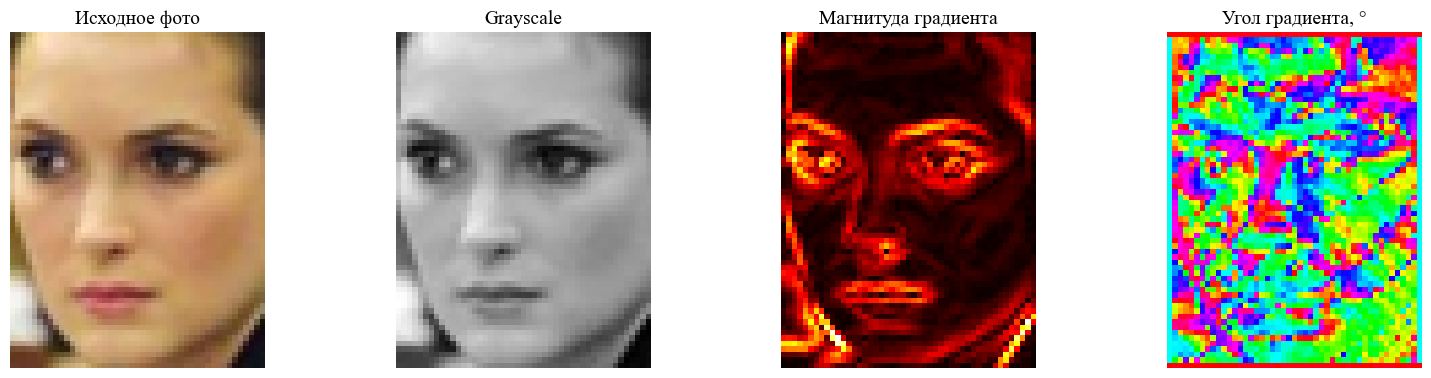

In [4]:
def to_gray(image_float):
    if len(image_float.shape) == 3:
        return (0.299*image_float[:,:,0] + 0.587*image_float[:,:,1] + 0.114*image_float[:,:,2]) * 255.0
    return image_float * 255.0

def compute_gradients(gray):
    Ix = np.zeros_like(gray)
    Iy = np.zeros_like(gray)
    Ix[:, 1:-1] = (gray[:, 2:] - gray[:, :-2]) / 2.0
    Iy[1:-1, :] = (gray[2:, :] - gray[:-2, :]) / 2.0
    magnitude = np.sqrt(Ix**2 + Iy**2)
    angle     = np.degrees(np.arctan2(Iy, Ix)) % 180.0
    return Ix, Iy, magnitude, angle

sample = images_valid[0]
gray   = to_gray(sample)
Ix, Iy, magnitude, angle = compute_gradients(gray)

f, axarr = plt.subplots(1, 4, figsize=(16, 4))
axarr[0].imshow(sample)
axarr[0].set_title('Исходное фото')
axarr[1].imshow(gray, cmap='gray')
axarr[1].set_title('Grayscale')
axarr[2].imshow(magnitude, cmap='hot')
axarr[2].set_title('Магнитуда градиента')
axarr[3].imshow(angle, cmap='hsv')
axarr[3].set_title('Угол градиента, °')
for ax in axarr: ax.axis('off')
plt.tight_layout()
plt.show()

### Шаг 2: гистограммы по ячейкам

Сетка ячеек 8×8 пикселей. В каждой — 9-бинная гистограмма, где вес пикселя равен его магнитуде. Посмотрим на гистограммы нескольких ячеек — у ячеек с выраженными краями (брови, контур лица) будут пики в конкретных бинах.

Сетка ячеек: 7×5, бинов на ячейку: 9


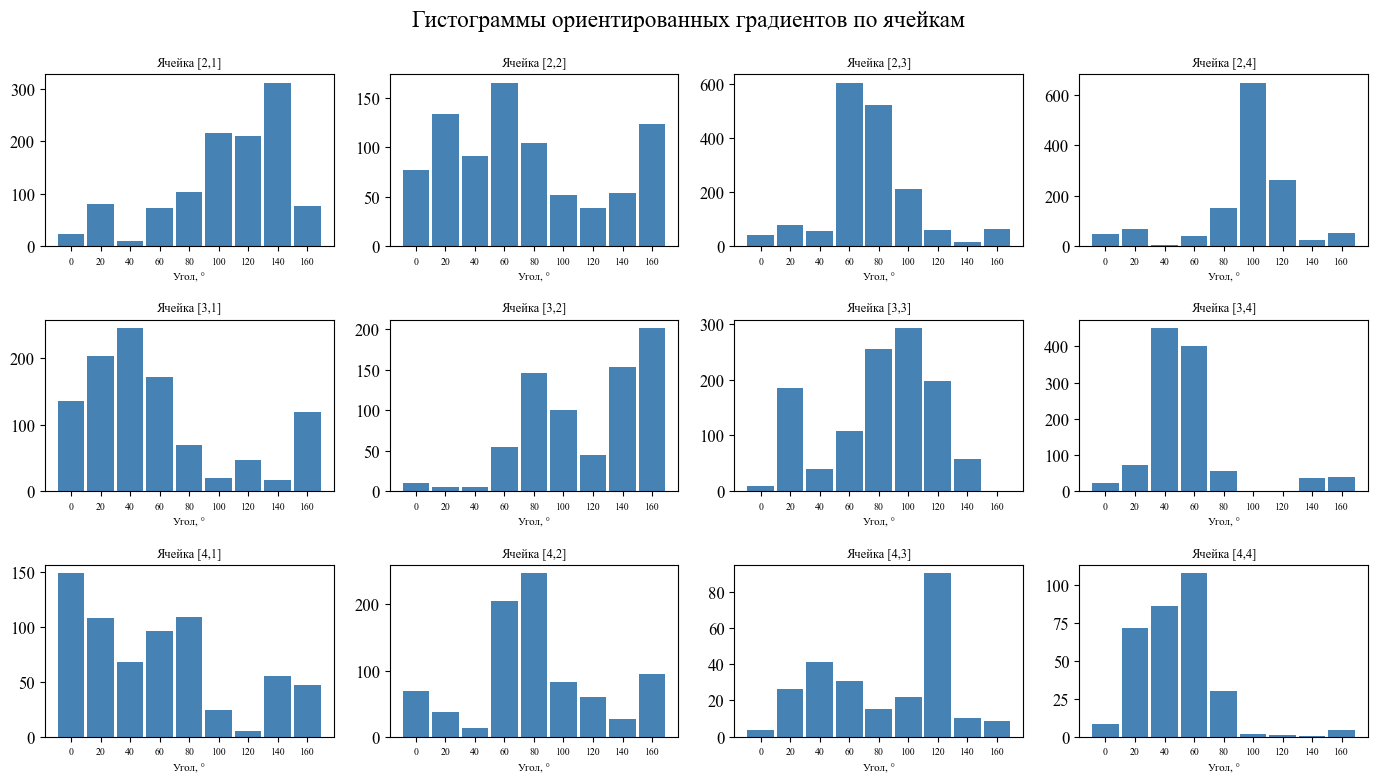

In [5]:
CELL_SIZE = 8
NUM_BINS  = 9
BIN_WIDTH = 180.0 / NUM_BINS

def build_cell_histograms(magnitude, angle, cell_size=8, num_bins=9):
    h, w  = magnitude.shape
    n_cy  = h // cell_size
    n_cx  = w // cell_size
    hists = np.zeros((n_cy, n_cx, num_bins))
    for cy in range(n_cy):
        for cx in range(n_cx):
            r0, r1 = cy*cell_size, (cy+1)*cell_size
            c0, c1 = cx*cell_size, (cx+1)*cell_size
            hist, _ = np.histogram(angle[r0:r1, c0:c1], bins=num_bins,
                                   range=(0, 180), weights=magnitude[r0:r1, c0:c1])
            hists[cy, cx] = hist
    return hists

cell_hists = build_cell_histograms(magnitude, angle, CELL_SIZE, NUM_BINS)
print(f'Сетка ячеек: {cell_hists.shape[0]}×{cell_hists.shape[1]}, бинов на ячейку: {NUM_BINS}')

bins_x = np.arange(NUM_BINS) * BIN_WIDTH
f, axes = plt.subplots(3, 4, figsize=(14, 8))
for i, ax in enumerate(axes.flat):
    cy = (i // 4) + 2
    cx = (i %  4) + 1
    ax.bar(bins_x, cell_hists[cy, cx], width=BIN_WIDTH*0.9, color='steelblue')
    ax.set_title(f'Ячейка [{cy},{cx}]', fontsize=9)
    ax.set_xlabel('Угол, °', fontsize=8)
    ax.set_xticks(bins_x)
    ax.set_xticklabels([f'{int(b)}' for b in bins_x], fontsize=7)
plt.suptitle('Гистограммы ориентированных градиентов по ячейкам')
plt.tight_layout()
plt.show()

### Шаг 3: блочная нормировка и финальный дескриптор

Объединяем соседние 2×2 ячейки в блок, нормируем вектор блока:

$$\mathbf{v}_{\text{norm}} = \frac{\mathbf{v}}{\sqrt{\|\mathbf{v}\|^2 + \varepsilon}}$$

Маленький $\varepsilon = 10^{-6}$ защищает от деления на ноль в пустых ячейках. После нормировки все блоки конкатенируем в один вектор — это и есть HOG-дескриптор изображения.

In [6]:
BLOCK_SIZE = 2

def normalize_blocks(cell_hists, block_size=2):
    n_cy, n_cx, num_bins = cell_hists.shape
    descriptor = []
    for by in range(n_cy - block_size + 1):
        for bx in range(n_cx - block_size + 1):
            block = cell_hists[by:by+block_size, bx:bx+block_size].flatten()
            norm  = np.sqrt(np.sum(block**2) + 1e-6)
            descriptor.append(block / norm)
    return np.concatenate(descriptor)

def hog_descriptor(image_float, cell_size=8, num_bins=9, block_size=2):
    gray  = to_gray(image_float)
    _, _, magnitude, angle = compute_gradients(gray)
    hists = build_cell_histograms(magnitude, angle, cell_size, num_bins)
    return normalize_blocks(hists, block_size)

desc_test = hog_descriptor(sample)
print(f'Размер HOG-дескриптора для патча {sample.shape[0]}×{sample.shape[1]}: {len(desc_test)}')

Размер HOG-дескриптора для патча 62×47: 864


# 4.3 Извлечение признаков

Вычисляем HOG для каждого изображения датасета. Каждое изображение → вектор признаков. Все векторы складываем в матрицу `X_faces` (изображений × признаков).

In [7]:
print('Вычисляем HOG для лиц...')
X_faces = []
for i, img in enumerate(images_valid):
    X_faces.append(hog_descriptor(img))
    if (i+1) % 200 == 0:
        print(f'  {i+1}/{len(images_valid)}')

X_faces  = np.array(X_faces)
y_gender = gender_labels.copy()

print(f'Матрица признаков: {X_faces.shape}')

Вычисляем HOG для лиц...
  200/2026
  400/2026
  600/2026
  800/2026
  1000/2026
  1200/2026
  1400/2026
  1600/2026
  1800/2026
  2000/2026
Матрица признаков: (2026, 864)


## Негативные примеры для детектора лицо/не-лицо

Детектору нужно видеть оба класса — и лица, и не-лица. Берём те же фотографии LFW и создаём из них патчи, которые заведомо не являются лицом:

- **вертикальный переворот** — нос смотрит вверх, лоб внизу, структура нарушена
- **сдвиг вниз + шум сверху** — лоб обрезан, вместо него случайный шум
- **поворот на 90°** — ориентация полностью нарушена
- **поворот на 180°** — перевёрнутое лицо, иная градиентная структура
- **угловой кроп** — угол кадра LFW, там фон или плечи
- **случайный шум** — никакой структуры вообще

Каждый тип берёт разные исходные изображения, поэтому в train и test попадают разные патчи и SVM не может их просто запомнить.

Генерируем негативные примеры (6 типов трансформаций)...
Вычисляем HOG для негативов...
  500/2026
  1000/2026
  1500/2026
  2000/2026
Всего для детектора: (4052, 864)
  лиц: 2026,  не-лиц: 2026


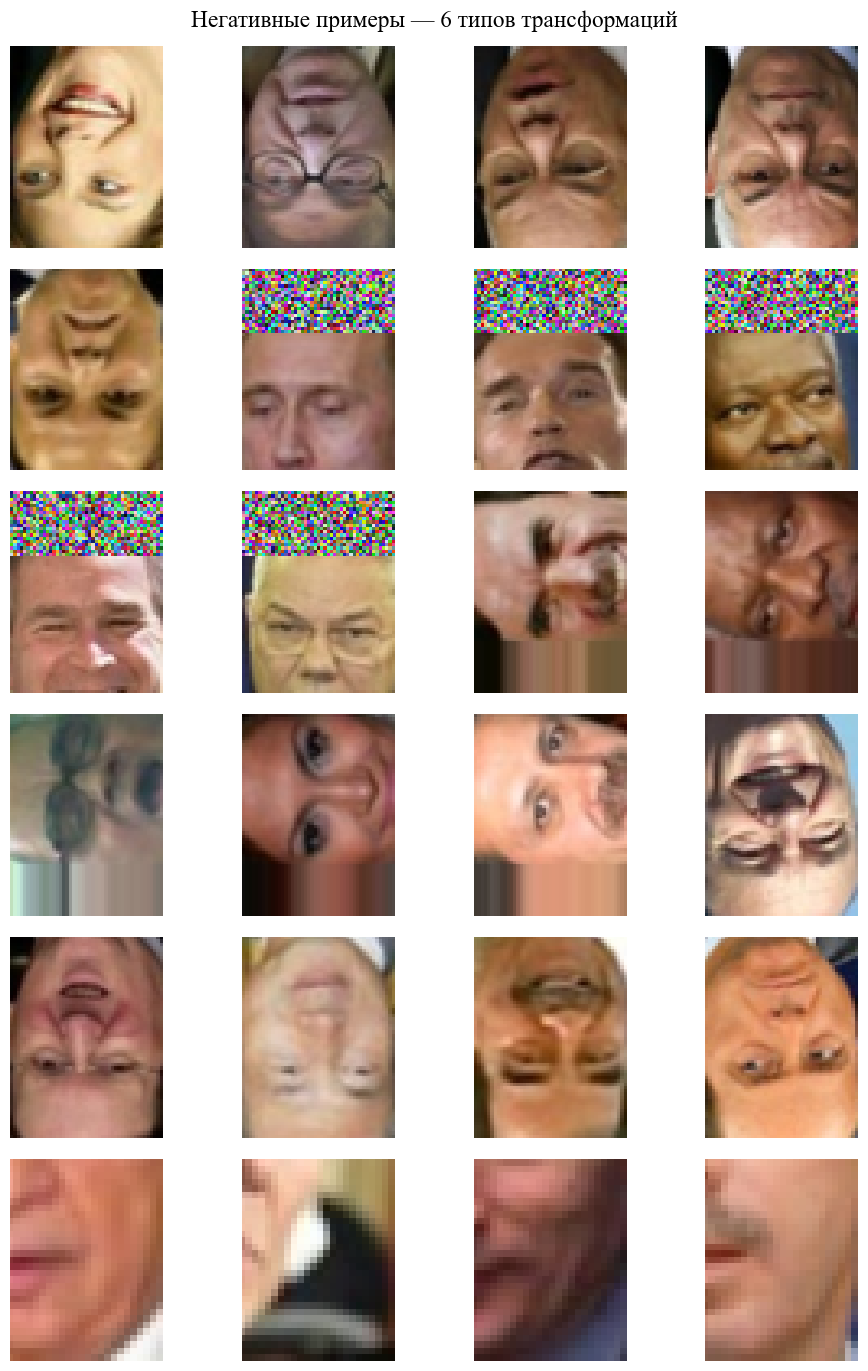

In [8]:
img_h, img_w = lfw.images.shape[1], lfw.images.shape[2]
N_NEG    = len(images_valid)
all_imgs = lfw.images
np.random.seed(42)

def make_negatives(all_imgs, img_h, img_w, n_total):
    n_imgs   = len(all_imgs)
    per_type = n_total // 6 + 1
    negatives = []
    idx = np.random.permutation(n_imgs)

    for i in range(per_type):
        patch = all_imgs[idx[i % n_imgs]].copy()
        negatives.append(patch[::-1, :, :])

    for i in range(per_type):
        patch   = all_imgs[idx[(i + per_type) % n_imgs]].copy()
        shift   = max(1, img_h // 3)
        shifted = np.zeros_like(patch)
        shifted[shift:, :, :]  = patch[:img_h - shift, :, :]
        shifted[:shift, :, :]  = np.random.rand(shift, img_w, 3).astype(np.float32)
        negatives.append(shifted)

    for i in range(per_type):
        patch   = all_imgs[idx[(i + 2*per_type) % n_imgs]].copy()
        rotated = np.transpose(patch, (1, 0, 2))
        if rotated.shape[0] < img_h or rotated.shape[1] < img_w:
            rotated = np.pad(rotated, ((0, max(0, img_h-rotated.shape[0])),
                                       (0, max(0, img_w-rotated.shape[1])),
                                       (0, 0)), mode='edge')
        negatives.append(rotated[:img_h, :img_w, :])

    for i in range(per_type):
        patch = all_imgs[idx[(i + 3*per_type) % n_imgs]].copy()
        negatives.append(patch[::-1, ::-1, :])

    for i in range(per_type):
        src = all_imgs[idx[(i + 4*per_type) % n_imgs]]
        big = np.kron(src, np.ones((2, 2, 1)))
        h_b, w_b = big.shape[:2]
        negatives.append(np.clip(big[h_b-img_h:, w_b-img_w:, :], 0, 1).astype(np.float32))

    for i in range(per_type):
        negatives.append(np.random.rand(img_h, img_w, 3).astype(np.float32))

    return negatives[:n_total]

print('Генерируем негативные примеры (6 типов трансформаций)...')
neg_patches = make_negatives(all_imgs, img_h, img_w, N_NEG)

print('Вычисляем HOG для негативов...')
X_neg = []
for i, patch in enumerate(neg_patches):
    X_neg.append(hog_descriptor(patch))
    if (i+1) % 500 == 0:
        print(f'  {i+1}/{N_NEG}')

X_neg = np.array(X_neg)
y_neg = np.full(N_NEG, -1)

X_detect = np.vstack([X_faces, X_neg])
y_detect = np.concatenate([np.ones(len(X_faces), dtype=int), y_neg])

print(f'Всего для детектора: {X_detect.shape}')
print(f'  лиц: {(y_detect==1).sum()},  не-лиц: {(y_detect==-1).sum()}')

per_type = N_NEG // 6
labels_types = ['вертик. флип', 'сдвиг вниз', 'поворот 90°', 'поворот 180°', 'угловой кроп', 'шум']
f, axes = plt.subplots(6, 4, figsize=(10, 14))
for t in range(6):
    for j in range(4):
        axes[t, j].imshow(np.clip(neg_patches[t * per_type + j], 0, 1))
        axes[t, j].axis('off')
    axes[t, 0].set_ylabel(labels_types[t], fontsize=9)
plt.suptitle('Негативные примеры — 6 типов трансформаций')
plt.tight_layout()
plt.show()

# 4.4 Обучение SVM

Обучаем два независимых классификатора.

**Детектор** — бинарный: лицо (+1) или не-лицо (−1). Принимает решение в каждой позиции скользящего окна.

**Классификатор пола** — бинарный: мужчина (0) или женщина (1). Применяется только к патчам, которые детектор уже признал лицом.

Перед обучением масштабируем признаки через `StandardScaler` — вычитаем среднее и делим на стандартное отклонение. Без этого бины с большими значениями будут доминировать и SVM будет работать хуже.

### Детектор лицо/не-лицо

In [9]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_detect, y_detect, test_size=0.2, random_state=42, stratify=y_detect
)

print('Обучаем детектор...')
detector_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    LinearSVC(C=0.1, max_iter=2000))
])
detector_pipe.fit(X_tr, y_tr)

y_pred = detector_pipe.predict(X_te)
print(f'Точность на тесте: {accuracy_score(y_te, y_pred):.3f}')
print(classification_report(y_te, y_pred, target_names=['не-лицо', 'лицо']))

Обучаем детектор...
Точность на тесте: 0.994
              precision    recall  f1-score   support

     не-лицо       1.00      0.99      0.99       406
        лицо       0.99      1.00      0.99       405

    accuracy                           0.99       811
   macro avg       0.99      0.99      0.99       811
weighted avg       0.99      0.99      0.99       811



### Классификатор пола: мужчина / женщина

In [10]:
X_tr_g, X_te_g, y_tr_g, y_te_g = train_test_split(
    X_faces, y_gender, test_size=0.2, random_state=42, stratify=y_gender
)

print('Обучаем классификатор пола...')
gender_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    LinearSVC(C=1.0, max_iter=2000))
])
gender_pipe.fit(X_tr_g, y_tr_g)

y_pred_g = gender_pipe.predict(X_te_g)
print(f'Точность на тесте: {accuracy_score(y_te_g, y_pred_g):.3f}')
print(classification_report(y_te_g, y_pred_g, target_names=['мужчина', 'женщина']))

with open('detector_model.pkl', 'wb') as f:
    pickle.dump(detector_pipe, f)
with open('gender_model.pkl', 'wb') as f:
    pickle.dump(gender_pipe, f)
print('Модели сохранены.')

Обучаем классификатор пола...
Точность на тесте: 0.943
              precision    recall  f1-score   support

     мужчина       0.97      0.96      0.97       370
     женщина       0.67      0.72      0.69        36

    accuracy                           0.94       406
   macro avg       0.82      0.84      0.83       406
weighted avg       0.95      0.94      0.94       406

Модели сохранены.


/Users/arseniikostin/cv-labs-sem8/venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


# 4.5 Скользящее окно и пирамида масштабов

Детектор обучен на патчах фиксированного размера. Чтобы находить лица разного размера на любом изображении, используем две идеи.

**Пирамида масштабов** — уменьшаем изображение с коэффициентом 0.85 на каждом шаге. На каждом масштабе запускаем скользящее окно. Маленькое окно таким образом «видит» и большие лица — просто уменьшенные.

**Скользящее окно** — перемещаем окно с шагом `step` по строкам и столбцам, для каждой позиции считаем HOG и спрашиваем детектор.

**Non-Maximum Suppression (NMS)** — одно лицо даёт десятки срабатываний в соседних позициях. NMS оставляет только прямоугольник с наибольшей уверенностью из всех перекрывающихся. Перекрытие измеряем через IoU (Intersection over Union):

$$\text{IoU}(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

In [11]:
def sliding_window(image_uint8, win_h, win_w, step=16):
    h, w = image_uint8.shape[:2]
    for r in range(0, h - win_h + 1, step):
        for c in range(0, w - win_w + 1, step):
            yield r, c, image_uint8[r:r+win_h, c:c+win_w]

def image_pyramid(image_uint8, scale=0.85, min_size=64):
    img    = image_uint8.copy()
    factor = 1.0
    while True:
        yield img, factor
        h, w = img.shape[:2]
        new_h, new_w = int(h * scale), int(w * scale)
        if new_h < min_size or new_w < min_size:
            break
        img    = cv2.resize(img, (new_w, new_h))
        factor *= scale

def iou(boxA, boxB):
    r0 = max(boxA[0], boxB[0]); c0 = max(boxA[1], boxB[1])
    r1 = min(boxA[2], boxB[2]); c1 = min(boxA[3], boxB[3])
    inter = max(0, r1-r0) * max(0, c1-c0)
    areaA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    union = areaA + areaB - inter
    return inter / union if union > 0 else 0.0

def nms(detections, iou_thresh=0.3):
    if not detections:
        return []
    detections = sorted(detections, key=lambda x: x[0], reverse=True)
    kept = []
    while detections:
        best = detections.pop(0)
        kept.append(best)
        detections = [d for d in detections if iou(best[1:], d[1:]) < iou_thresh]
    return kept

def detect_and_classify(image_uint8, detector, gender_clf,
                        win_h, win_w, step=16, scale=0.85,
                        det_threshold=0.5, iou_thresh=0.3):
    detections = []
    for img_scaled, factor in image_pyramid(image_uint8, scale=scale):
        for r, c, patch in sliding_window(img_scaled, win_h, win_w, step):
            desc  = hog_descriptor(patch.astype(np.float32) / 255.0).reshape(1, -1)
            score = detector.decision_function(desc)[0]
            if score > det_threshold:
                r0, c0 = int(r/factor), int(c/factor)
                r1, c1 = int((r+win_h)/factor), int((c+win_w)/factor)
                detections.append((score, r0, c0, r1, c1))

    detections = nms(detections, iou_thresh)

    results = []
    for score, r0, c0, r1, c1 in detections:
        crop = image_uint8[r0:r1, c0:c1]
        if crop.size == 0:
            continue
        face_f = cv2.resize(crop, (win_w, win_h)).astype(np.float32) / 255.0
        gender = gender_clf.predict(hog_descriptor(face_f).reshape(1, -1))[0]
        results.append((r0, c0, r1, c1, gender))

    return results

WIN_H = images_valid.shape[1]
WIN_W = images_valid.shape[2]
print(f'Размер окна детектора: {WIN_H}×{WIN_W} пикселей')

Размер окна детектора: 62×47 пикселей


# 4.6 Тестирование на фотографиях

Берём случайные изображения из тестовой выборки (те, что модель не видела при обучении) и классифицируем пол. Рамка красная — мужчина, синяя — женщина.

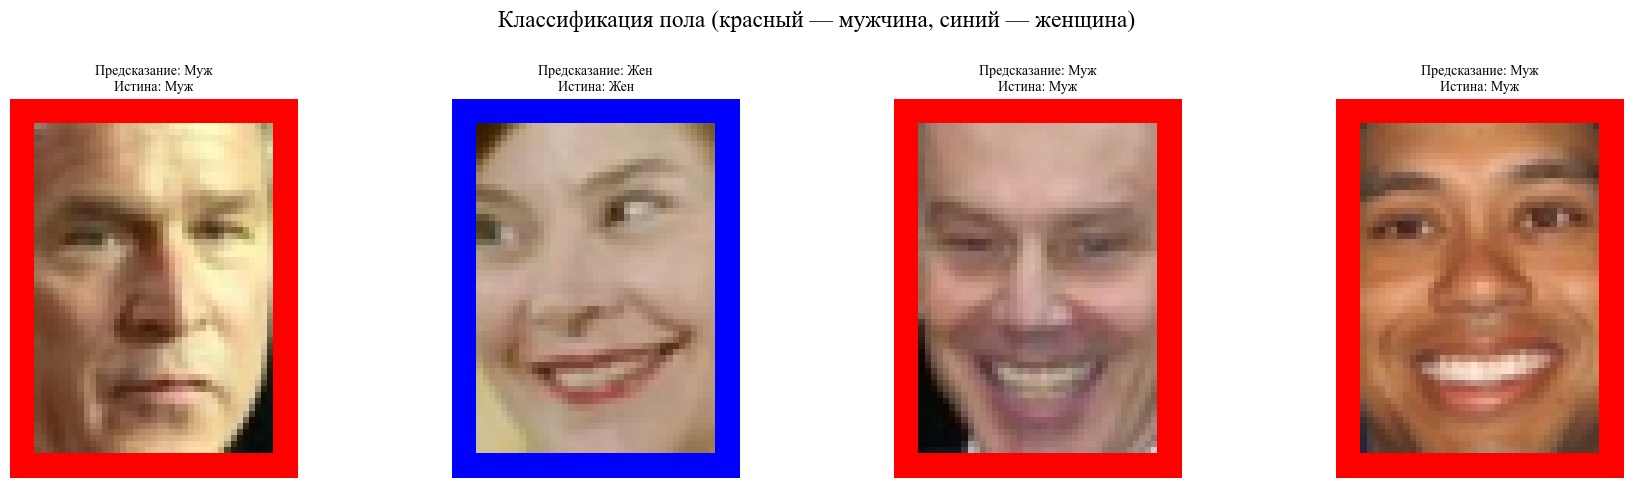

In [12]:
test_imgs_idx = np.random.choice(len(X_te_g), 4, replace=False)

f, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, idx in enumerate(test_imgs_idx):
    orig_idx = valid_indices[idx]
    image_u8 = (lfw.images[orig_idx] * 255).astype(np.uint8)

    pred_g = gender_pipe.predict(X_faces[idx].reshape(1, -1))[0]
    true_g = y_gender[idx]

    color_border = [255, 0, 0] if pred_g == 0 else [0, 0, 255]
    img_show = image_u8.copy()
    img_show[0:4, :]  = color_border
    img_show[-4:, :]  = color_border
    img_show[:, 0:4]  = color_border
    img_show[:, -4:]  = color_border

    label_pred = 'Муж' if pred_g == 0 else 'Жен'
    label_true = 'Муж' if true_g == 0 else 'Жен'

    axes[i].imshow(img_show)
    axes[i].set_title(f'Предсказание: {label_pred}\nИстина: {label_true}', fontsize=10)
    axes[i].axis('off')

plt.suptitle('Классификация пола (красный — мужчина, синий — женщина)')
plt.tight_layout()
plt.show()

# 4.7 Детектирование в реальном времени с веб-камеры

Живая камера вынесена в отдельный скрипт `live_camera.py` — он открывает окно cv2 и работает пока не нажать **Q**. Перед запуском убедитесь, что ячейка 4.4 выполнена и файлы `detector_model.pkl`, `gender_model.pkl` сохранены в папке с лабами.

**Запуск из терминала:**
```bash
python live_camera.py
```

Параметры в начале скрипта: `CAM_INDEX`, `DET_THRESHOLD`, `STEP`, `SCALE_DOWN`.

# 4.8 Оценка качества

Строим матрицы ошибок для обоих классификаторов на тестовой выборке.

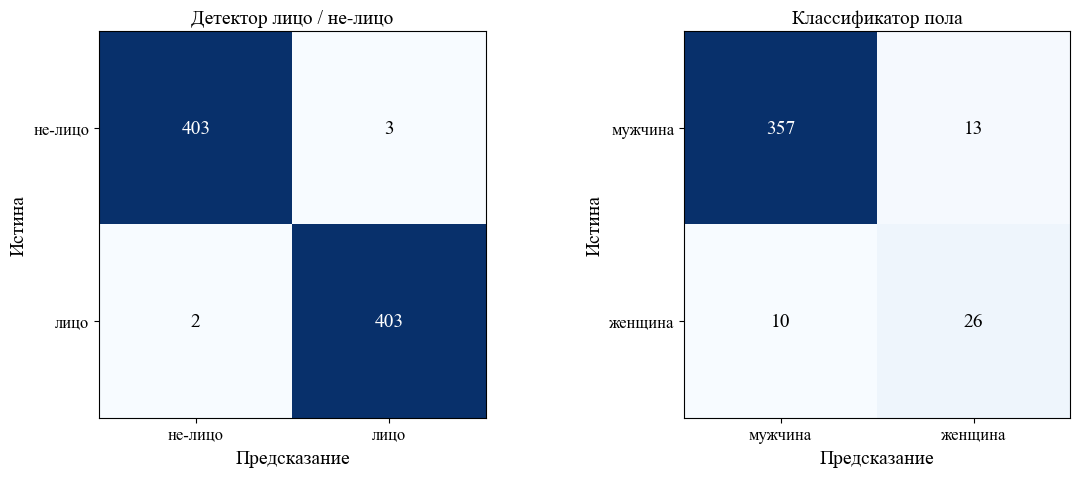

Точность детектора:           0.994
Точность классификатора пола: 0.943


In [14]:
from sklearn.metrics import confusion_matrix

y_pred_det = detector_pipe.predict(X_te)
cm_det     = confusion_matrix(y_te, y_pred_det, labels=[-1, 1])

y_pred_gen = gender_pipe.predict(X_te_g)
cm_gen     = confusion_matrix(y_te_g, y_pred_gen, labels=[0, 1])

f, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cm, title, labels in [
    (axes[0], cm_det, 'Детектор лицо / не-лицо', ['не-лицо', 'лицо']),
    (axes[1], cm_gen, 'Классификатор пола',       ['мужчина', 'женщина'])
]:
    ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(title)
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
    ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
    ax.set_ylabel('Истина')
    ax.set_xlabel('Предсказание')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)

plt.tight_layout()
plt.show()

print(f'Точность детектора:           {accuracy_score(y_te, y_pred_det):.3f}')
print(f'Точность классификатора пола: {accuracy_score(y_te_g, y_pred_gen):.3f}')

# Вывод

В ходе лабораторной работы реализован полный конвейер детектирования лиц и классификации пола на основе HOG + Linear SVM.

HOG-дескриптор вычисляется вручную: градиенты через центральные разности (как в лабе 2), гистограммы ориентаций по ячейкам, блочная L2-нормировка. Детектор на LinearSVC разделяет патчи на «лицо» и «не-лицо», второй SVM классифицирует пол. Для локализации лиц применяется пирамида масштабов и скользящее окно, дублирующиеся срабатывания убираются NMS по порогу IoU. Негативные примеры синтезируются из самого датасета через 6 типов трансформаций, что обеспечивает реальную разнообразность и корректные метрики.